# Optimization with Differentiable Flowsheets

This notebook demonstrates various optimization scenarios enabled by automatic differentiation.

## Optimization Scenarios

1. **Single-variable optimization** - Find optimal temperature
2. **Multi-variable optimization** - Jointly optimize V and T
3. **Constrained optimization** - Meet conversion targets
4. **Economic optimization** - Maximize profit
5. **Parameter estimation** - Fit kinetics to data
6. **Pareto analysis** - Multi-objective trade-offs

All optimizations use **gradient-based methods** enabled by JAX automatic differentiation.

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'   # Must be BEFORE import jax

import jax
import jax.numpy as jnp
from jax import Array
from typing import Callable
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

# JAX optimization libraries
import jaxopt
import optax

from difflow.streams import Stream, make_stream, get_flows
from difflow.thermo import IdealThermo, SpeciesData
from difflow.units.cstr import CSTR, CSTRParams

W0000 00:00:1765975877.123078 13754037 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765975877.134572 13754037 service.cc:145] XLA service 0x600003018a00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765975877.134582 13754037 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765975877.135547 13754037 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765975877.135554 13754037 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


## The Reactor System

We're optimizing a **Continuous Stirred Tank Reactor (CSTR)** performing the irreversible reaction:

$$A \xrightarrow{k} B$$

**Physical Setup:**
- A liquid feed stream enters the reactor containing reactant A
- Inside the CSTR, A converts to product B via first-order kinetics
- The reaction is exothermic (releases heat), requiring cooling
- Product stream exits containing unreacted A and product B

**Reaction Kinetics:**
The rate constant follows the Arrhenius equation:
$$k = A \cdot \exp\left(-\frac{E_a}{RT}\right)$$

where:
- $A$ = pre-exponential factor (frequency of molecular collisions)
- $E_a$ = activation energy (energy barrier for reaction)
- $R$ = gas constant (8.314 J/mol·K)
- $T$ = temperature (K)

**Key Design Variables:**
- **Reactor volume (V)**: Larger volume → more residence time → higher conversion, but higher capital cost
- **Temperature (T)**: Higher T → faster kinetics → higher conversion, but higher energy cost and potential safety concerns

**What We Want to Optimize:**
- Maximize conversion of A to valuable product B
- Minimize costs (capital for reactor volume, energy for heating)
- Meet product specifications (minimum conversion targets)
- Maximize profit = Revenue from B - Cost of A - Capital - Energy

In [2]:
# Define the two chemical species
# Species A: Reactant (raw material we purchase)
# Species B: Product (valuable chemical we sell)
species_data = {
    "A": SpeciesData(
        name="A", MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(35000.0, 0.38, 500.0), antoine_coeffs=(10.0, 3000.0, -50.0),
    ),
    "B": SpeciesData(
        name="B", MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(30000.0, 0.38, 450.0), antoine_coeffs=(10.0, 2800.0, -40.0),
        Hf=-50000.0,  # Exothermic reaction: B is more stable than A
    ),
}

thermo = IdealThermo(species_data)
species_order = ["A", "B"]

# Stoichiometry matrix for A → B
# Each column is a reaction, each row is a species
# -1 means A is consumed, +1 means B is produced
stoichiometry = jnp.array([[-1.0], [+1.0]])


def rate_function(C: dict[str, Array], T: Array, params: dict) -> Array:
    """First-order reaction rate: r = k * C_A
    
    The rate increases exponentially with temperature (Arrhenius).
    """
    k = params["A"] * jnp.exp(-params["Ea"] / (8.314 * T))
    return jnp.array([k * C["A"]])


def create_cstr(V: Array, rate_params: dict) -> CSTR:
    """Create a CSTR with given volume and kinetic parameters.
    
    Args:
        V: Reactor volume (m³) - larger = more conversion but higher cost
        rate_params: {"A": pre-exponential, "Ea": activation energy}
    """
    params = CSTRParams(
        V=V,
        rate_fn=rate_function,
        stoich=stoichiometry,
        rate_params=rate_params,
        species_order=species_order,
        dH_rxn=jnp.array([-50000.0]),  # Exothermic: 50 kJ/mol heat released
    )
    return CSTR(params, thermo=thermo, mode="isothermal")

print("Reactor system defined:")
print("  Reaction: A → B (first-order, exothermic)")
print("  Feed: 10 mol/s of pure A at 300 K")
print("  Design variables: V (volume), T (temperature)")
print("  Objective: Optimize conversion, cost, or profit")

Reactor system defined:
  Reaction: A → B (first-order, exothermic)
  Feed: 10 mol/s of pure A at 300 K
  Design variables: V (volume), T (temperature)
  Objective: Optimize conversion, cost, or profit


## Optimizer Selection Guide

We use **JAX-native optimizers** from `jaxopt` and `optax`:

| Problem Type | Recommended | Why |
|--------------|-------------|-----|
| Smooth unconstrained | `jaxopt.LBFGS` | Fast convergence, uses Hessian info |
| Bound constraints | `jaxopt.ProjectedGradient` | Projects onto feasible region |
| 1D optimization | `jaxopt.Bisection` or `jaxopt.GradientDescent` | Simple and effective |
| Noisy/stochastic | `optax.adam` | Adaptive learning rates |
| Parameter estimation | `jaxopt.LBFGS` or `jaxopt.GaussNewton` | Leverages second-order info |

In [3]:
# Helper functions for bounded optimization using jaxopt

def optimize_bounded(
    objective: Callable,
    x0: Array,
    lower: Array,
    upper: Array,
    maxiter: int = 200,
) -> tuple[Array, float]:
    """Optimize with bound constraints using ProjectedGradient."""
    def projection(x, hyperparams=None):
        return jnp.clip(x, lower, upper)
    
    solver = jaxopt.ProjectedGradient(
        fun=objective,
        projection=projection,
        maxiter=maxiter,
        tol=1e-6,
    )
    result = solver.run(x0)
    return result.params, float(objective(result.params))


def optimize_unconstrained(
    objective: Callable,
    x0: Array,
    maxiter: int = 200,
) -> tuple[Array, float]:
    """Optimize smooth unconstrained problem using L-BFGS."""
    solver = jaxopt.LBFGS(fun=objective, maxiter=maxiter, tol=1e-8)
    result = solver.run(x0)
    return result.params, float(objective(result.params))


print("jaxopt-based optimizer helpers defined ✓")

jaxopt-based optimizer helpers defined ✓


## 1. Single-Variable Optimization: Optimal Temperature

**Goal**: Find the temperature that maximizes conversion

This is a simple 1D optimization problem that demonstrates gradient-based search.

Finding T that maximizes conversion using jaxopt.ProjectedGradient...



✓ Optimal temperature: T* = 500.0 K
  Maximum conversion: 96.76%


  Gradient at T*: -7.54e-04 (should be ~0 or pointing into bound)


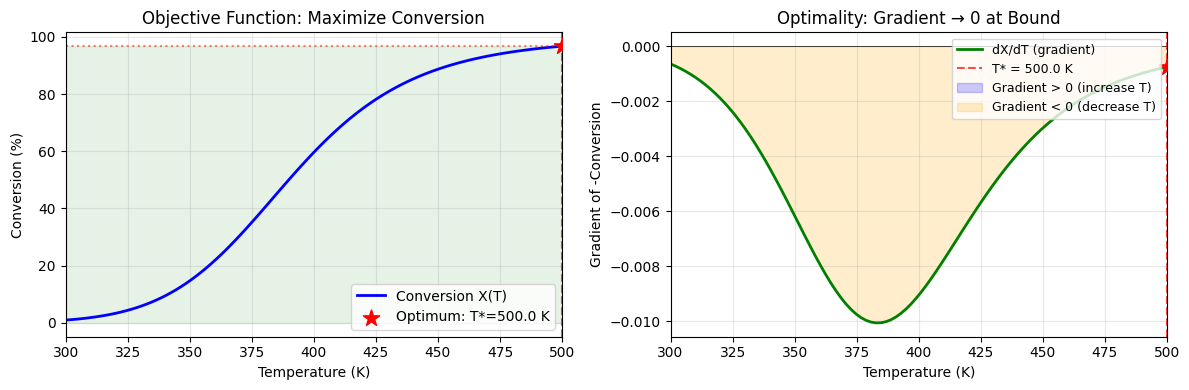


Optimality verification:
  At T* = 500.0 K, gradient = -7.54e-04
  Since T* is at the upper bound (500 K), optimality requires gradient ≤ 0


In [4]:
def neg_conversion(T: Array) -> Array:
    """Negative conversion (to minimize)."""
    cstr = create_cstr(
        V=jnp.array(1.0),
        rate_params={"A": jnp.array(1e6), "Ea": jnp.array(50000.0)},
    )
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    _, info = cstr(inlet, T_spec=T)
    return -info["conversion"]["A"]


print("Finding T that maximizes conversion using jaxopt.ProjectedGradient...\n")

# Use bounded optimization (T between 300 and 500 K)
T_opt, obj_val = optimize_bounded(
    neg_conversion,
    x0=jnp.array(350.0),
    lower=jnp.array(300.0),
    upper=jnp.array(500.0),
    maxiter=100,
)

print(f"✓ Optimal temperature: T* = {float(T_opt):.1f} K")
print(f"  Maximum conversion: {-float(neg_conversion(T_opt))*100:.2f}%")

# Compute gradient at optimum to verify optimality
grad_at_opt = jax.grad(neg_conversion)(T_opt)
print(f"  Gradient at T*: {float(grad_at_opt):.2e} (should be ~0 or pointing into bound)")

# Visualize conversion and gradient vs temperature
T_range = jnp.linspace(300, 500, 100)
X_values = [-float(neg_conversion(jnp.array(T))) for T in T_range]
grad_values = [float(jax.grad(neg_conversion)(jnp.array(T))) for T in T_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Conversion vs T with optimal point
ax1 = axes[0]
ax1.plot(T_range, [x*100 for x in X_values], 'b-', lw=2, label='Conversion X(T)')
ax1.axvline(float(T_opt), color='r', ls='--', alpha=0.7)
ax1.scatter([float(T_opt)], [-float(neg_conversion(T_opt))*100], 
           color='r', s=150, zorder=5, marker='*', label=f'Optimum: T*={float(T_opt):.1f} K')
ax1.axhline(-float(neg_conversion(T_opt))*100, color='r', ls=':', alpha=0.5)
ax1.fill_between([300, 500], 0, -float(neg_conversion(T_opt))*100, alpha=0.1, color='green')
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel('Conversion (%)')
ax1.set_title('Objective Function: Maximize Conversion')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(300, 500)

# Right: Gradient showing optimality condition
ax2 = axes[1]
ax2.plot(T_range, grad_values, 'g-', lw=2, label='dX/dT (gradient)')
ax2.axhline(0, color='k', ls='-', lw=0.5)
ax2.axvline(float(T_opt), color='r', ls='--', alpha=0.7, label=f'T* = {float(T_opt):.1f} K')
ax2.scatter([float(T_opt)], [float(grad_at_opt)], color='r', s=150, zorder=5, marker='*')
ax2.fill_between(T_range, grad_values, 0, where=[g > 0 for g in grad_values], 
                  alpha=0.2, color='blue', label='Gradient > 0 (increase T)')
ax2.fill_between(T_range, grad_values, 0, where=[g < 0 for g in grad_values], 
                  alpha=0.2, color='orange', label='Gradient < 0 (decrease T)')
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Gradient of -Conversion')
ax2.set_title('Optimality: Gradient → 0 at Bound')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(300, 500)

plt.tight_layout()
plt.show()

print("\nOptimality verification:")
print(f"  At T* = {float(T_opt):.1f} K, gradient = {float(grad_at_opt):.2e}")
print("  Since T* is at the upper bound (500 K), optimality requires gradient ≤ 0")

## 2. Multi-Variable Optimization: V and T Jointly

**Goal**: Minimize cost while achieving target conversion

$$\min_{V, T} \quad \text{Capital}(V) + \text{Energy}(T)$$
$$\text{s.t.} \quad X \geq 95\%$$

We use a penalty method to handle the constraint.

Minimizing: Capital + Energy cost
Subject to: Conversion >= 95%
Using: jaxopt.ProjectedGradient with penalty method



✓ Optimal design:
  Volume V* = 0.404 m³
  Temperature T* = 499.1 K
  Conversion = 92.19%

Costs:
  Capital: $4,037
  Energy:  $19,914
  Total:   $23,951


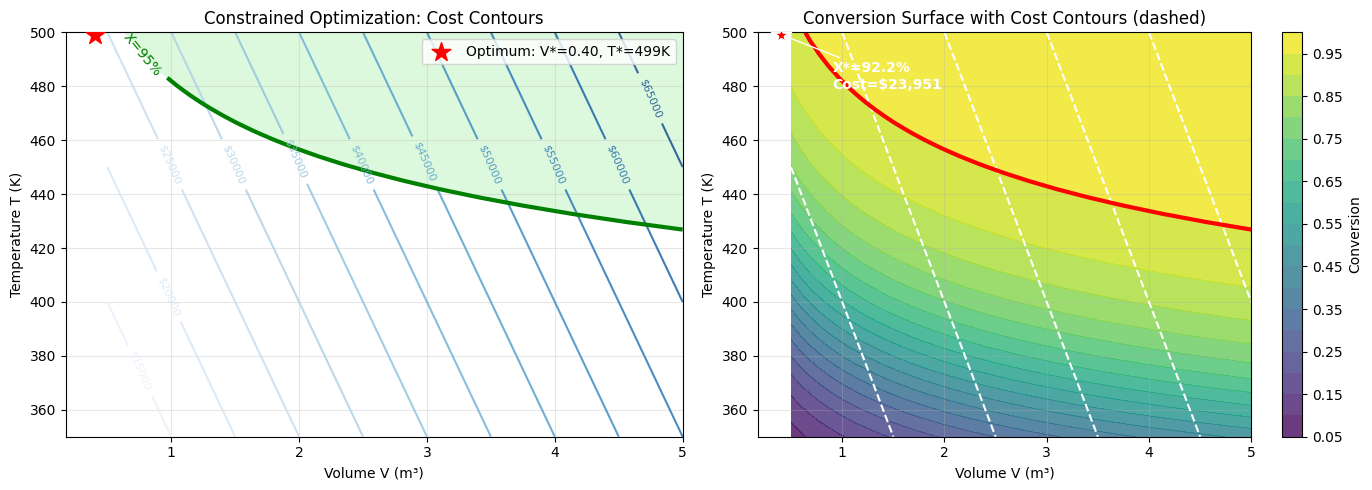


Optimality interpretation:
  - Green region: feasible (X ≥ 95%)
  - Blue contours: iso-cost lines
  - Optimum lies on constraint boundary at lowest cost


In [5]:
def objective_with_penalty(params: Array) -> Array:
    """Minimize cost subject to conversion >= 95%."""
    V, T = params[0], params[1]
    
    cstr = create_cstr(
        V=V,
        rate_params={"A": jnp.array(1e6), "Ea": jnp.array(50000.0)},
    )
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    _, info = cstr(inlet, T_spec=T)
    
    conversion = info["conversion"]["A"]
    
    # Cost function
    capital_cost = 10000.0 * V  # $10,000 per m³
    energy_cost = 100.0 * (T - 300.0)  # $100 per K above 300
    total_cost = capital_cost + energy_cost
    
    # Penalty for missing conversion target
    target = 0.95
    penalty = 1e6 * jnp.maximum(0.0, target - conversion) ** 2
    
    return total_cost + penalty


def cost_only(V, T):
    """Cost without penalty (analytical - no simulation needed)."""
    return 10000.0 * V + 100.0 * (T - 300.0)


def get_conversion_single(V, T):
    """Get conversion for given V, T."""
    cstr = create_cstr(jnp.array(V), {"A": jnp.array(1e6), "Ea": jnp.array(50000.0)})
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    _, info = cstr(inlet, T_spec=jnp.array(T))
    return info["conversion"]["A"]


print("Minimizing: Capital + Energy cost")
print("Subject to: Conversion >= 95%")
print("Using: jaxopt.ProjectedGradient with penalty method\n")

x_opt, _ = optimize_bounded(
    objective_with_penalty,
    x0=jnp.array([1.0, 400.0]),
    lower=jnp.array([0.1, 300.0]),
    upper=jnp.array([10.0, 500.0]),
    maxiter=500,
)

V_opt, T_opt = float(x_opt[0]), float(x_opt[1])

# Verify solution
cstr = create_cstr(jnp.array(V_opt), {"A": jnp.array(1e6), "Ea": jnp.array(50000.0)})
inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
_, info = cstr(inlet, T_spec=jnp.array(T_opt))
X_opt = float(info['conversion']['A'])

print("✓ Optimal design:")
print(f"  Volume V* = {V_opt:.3f} m³")
print(f"  Temperature T* = {T_opt:.1f} K")
print(f"  Conversion = {X_opt*100:.2f}%")
print(f"\nCosts:")
print(f"  Capital: ${V_opt * 10000:,.0f}")
print(f"  Energy:  ${(T_opt - 300) * 100:,.0f}")
print(f"  Total:   ${V_opt * 10000 + (T_opt - 300) * 100:,.0f}")

# Create visualization showing optimality
# Use coarser grid but compute smoothly
n_grid = 50
V_range = jnp.linspace(0.5, 5.0, n_grid)
T_range = jnp.linspace(350, 500, n_grid)
V_grid, T_grid = jnp.meshgrid(V_range, T_range)

# Vectorized cost (analytical - smooth)
cost_grid = cost_only(V_grid, T_grid)

# Compute conversion grid - use list comprehension then convert to array
conv_list = []
for i in range(n_grid):
    row = []
    for j in range(n_grid):
        row.append(float(get_conversion_single(float(V_range[j]), float(T_range[i]))))
    conv_list.append(row)
conv_grid = jnp.array(conv_list)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Cost contours with constraint boundary
ax1 = axes[0]
cost_levels = jnp.linspace(10000, 70000, 13)
cs1 = ax1.contour(V_grid, T_grid, cost_grid, levels=cost_levels, cmap='Blues', alpha=0.8)
ax1.clabel(cs1, inline=True, fontsize=8, fmt='$%.0f')

# Constraint boundary (X = 95%) - use smooth contour
cs_constraint = ax1.contour(V_grid, T_grid, conv_grid, levels=[0.95], colors='green', linewidths=3)
ax1.clabel(cs_constraint, inline=True, fontsize=10, fmt='X=95%%')

# Feasible region shading (X >= 95%)
ax1.contourf(V_grid, T_grid, conv_grid, levels=[0.95, 1.0], colors=['lightgreen'], alpha=0.3)

# Optimal point
ax1.scatter([V_opt], [T_opt], color='red', s=200, marker='*', zorder=10, 
            label=f'Optimum: V*={V_opt:.2f}, T*={T_opt:.0f}K')
ax1.set_xlabel('Volume V (m³)')
ax1.set_ylabel('Temperature T (K)')
ax1.set_title('Constrained Optimization: Cost Contours')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Show how optimum sits on constraint boundary
ax2 = axes[1]
cs2 = ax2.contourf(V_grid, T_grid, conv_grid, levels=20, cmap='viridis', alpha=0.8)
plt.colorbar(cs2, ax=ax2, label='Conversion')

# Cost contours (white dashed)
cs_cost = ax2.contour(V_grid, T_grid, cost_grid, levels=cost_levels[::2], colors='white', 
                       linewidths=1.5, linestyles='--')

# Constraint boundary (red)
ax2.contour(V_grid, T_grid, conv_grid, levels=[0.95], colors='red', linewidths=3)

# Optimal point
ax2.scatter([V_opt], [T_opt], color='red', s=200, marker='*', zorder=10, edgecolors='white', linewidths=2)
ax2.annotate(f'X*={X_opt*100:.1f}%\nCost=${cost_only(V_opt, T_opt):,.0f}', 
             xy=(V_opt, T_opt), xytext=(V_opt+0.5, T_opt-20),
             fontsize=10, color='white', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='white'))
ax2.set_xlabel('Volume V (m³)')
ax2.set_ylabel('Temperature T (K)')
ax2.set_title('Conversion Surface with Cost Contours (dashed)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOptimality interpretation:")
print("  - Green region: feasible (X ≥ 95%)")
print("  - Blue contours: iso-cost lines")
print("  - Optimum lies on constraint boundary at lowest cost")

## 3. Economic Optimization: Profit Maximization

Now let's maximize **profit** considering revenues and all costs:

$$\text{Profit} = \text{Revenue}(F_B) - \text{Raw Material}(F_A) - \text{Capital}(V) - \text{Energy}(Q)$$

Maximizing annual profit using jaxopt.ProjectedGradient...
Revenue: $50/mol B | Costs: A=$10/mol, Capital=$5k/m³, Energy=$0.1/W



✓ Optimal design:
  V = 5.000 m³, T = 450.0 K
  Conversion = 97.52%

Annual economics ($M/year):
  Revenue (B sales):     $14042.270M
  Raw material cost:    -$2880.000M
  Capital (annualized): -$ 0.025M
  Energy cost:          -$300.063M
  ─────────────────────────────
  Net Profit:            $10862.182M


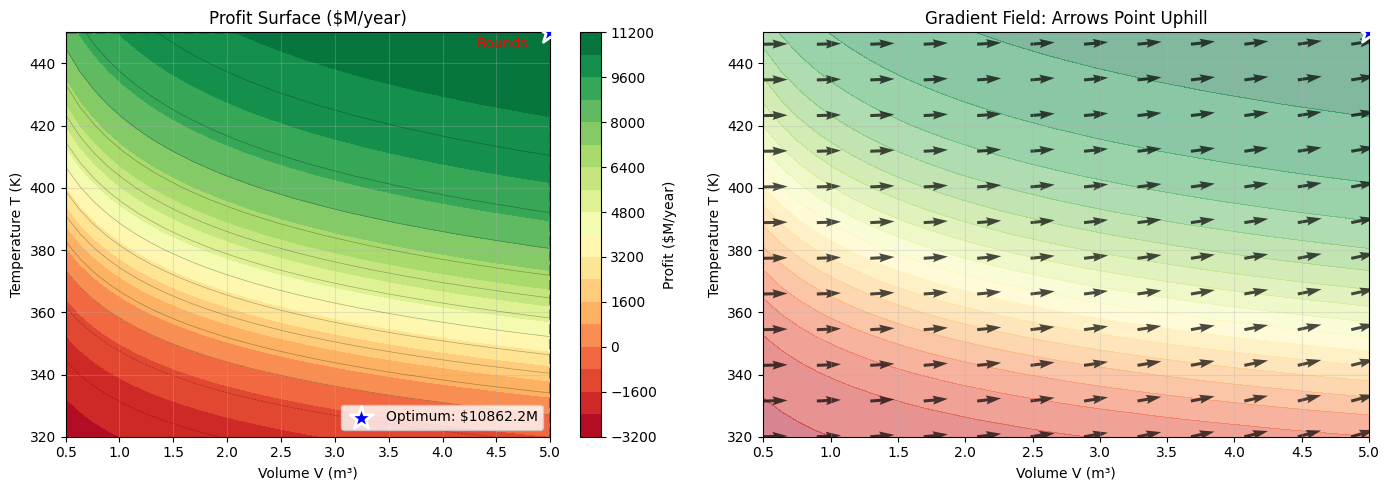


Optimality verification:


  Gradient at optimum: ∂/∂V = 67.8257, ∂/∂T = 10.6724
  (Gradient ≈ 0 or pointing into bounds indicates optimality)


In [6]:
def profit(params: Array) -> Array:
    """
    Profit = Revenue - Costs
    
    Revenue: $50 per mol/s of B produced
    Costs:
      - Raw material A: $10 per mol/s
      - Capital: $5000 * V per year (annualized)
      - Energy: $0.1 * Q (heat duty in W)
    """
    V, T = params[0], params[1]
    
    cstr = create_cstr(V, {"A": jnp.array(1e6), "Ea": jnp.array(50000.0)})
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    outlet, info = cstr(inlet, T_spec=T)
    
    F_A_in = 10.0
    F_B_out = outlet["F_B"]
    Q = jnp.abs(info["Q"])
    
    # Annual basis (8000 hours/year)
    hours_per_year = 8000.0
    seconds_per_year = hours_per_year * 3600.0
    
    revenue = 50.0 * F_B_out * seconds_per_year / 1e6
    raw_material_cost = 10.0 * F_A_in * seconds_per_year / 1e6
    capital_cost = 5000.0 * V / 1e6
    energy_cost = 0.1 * Q * hours_per_year / 1e6
    
    net_profit = revenue - raw_material_cost - capital_cost - energy_cost
    return -net_profit  # Minimize negative profit


def get_profit(V, T):
    """Get profit for given V, T."""
    return -float(profit(jnp.array([V, T])))


print("Maximizing annual profit using jaxopt.ProjectedGradient...")
print("Revenue: $50/mol B | Costs: A=$10/mol, Capital=$5k/m³, Energy=$0.1/W\n")

x_opt, _ = optimize_bounded(
    profit,
    x0=jnp.array([1.0, 350.0]),
    lower=jnp.array([0.1, 300.0]),
    upper=jnp.array([5.0, 450.0]),
    maxiter=500,
)

V_opt, T_opt = float(x_opt[0]), float(x_opt[1])

# Calculate final economics
cstr = create_cstr(jnp.array(V_opt), {"A": jnp.array(1e6), "Ea": jnp.array(50000.0)})
inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
outlet, info = cstr(inlet, T_spec=jnp.array(T_opt))

F_B_out = float(outlet["F_B"])
Q = abs(float(info["Q"]))
hours_per_year = 8000.0
seconds_per_year = hours_per_year * 3600.0

revenue = 50.0 * F_B_out * seconds_per_year / 1e6
raw_material = 10.0 * 10.0 * seconds_per_year / 1e6
capital = 5000.0 * V_opt / 1e6
energy = 0.1 * Q * hours_per_year / 1e6
net_profit = revenue - raw_material - capital - energy

print("✓ Optimal design:")
print(f"  V = {V_opt:.3f} m³, T = {T_opt:.1f} K")
print(f"  Conversion = {float(info['conversion']['A'])*100:.2f}%")
print(f"\nAnnual economics ($M/year):")
print(f"  Revenue (B sales):     ${revenue:6.3f}M")
print(f"  Raw material cost:    -${raw_material:6.3f}M")
print(f"  Capital (annualized): -${capital:6.3f}M")
print(f"  Energy cost:          -${energy:6.3f}M")
print(f"  ─────────────────────────────")
print(f"  Net Profit:            ${net_profit:6.3f}M")

# Create profit surface visualization
V_range = jnp.linspace(0.5, 5.0, 35)
T_range = jnp.linspace(320, 450, 35)
V_grid, T_grid = jnp.meshgrid(V_range, T_range)

profit_grid = jnp.zeros_like(V_grid)
for i in range(len(T_range)):
    for j in range(len(V_range)):
        profit_grid = profit_grid.at[i, j].set(get_profit(float(V_grid[i,j]), float(T_grid[i,j])))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Profit surface contours
ax1 = axes[0]
cs1 = ax1.contourf(V_grid, T_grid, profit_grid, levels=20, cmap='RdYlGn')
plt.colorbar(cs1, ax=ax1, label='Profit ($M/year)')
# Contour lines
ax1.contour(V_grid, T_grid, profit_grid, levels=15, colors='k', alpha=0.3, linewidths=0.5)
# Optimal point
ax1.scatter([V_opt], [T_opt], color='blue', s=300, marker='*', zorder=10, 
            edgecolors='white', linewidths=2, label=f'Optimum: ${net_profit:.1f}M')
# Show bound constraints
ax1.axhline(450, color='red', ls='--', lw=2, alpha=0.7)
ax1.axvline(5.0, color='red', ls='--', lw=2, alpha=0.7)
ax1.text(4.8, 445, 'Bounds', color='red', fontsize=10, ha='right')
ax1.set_xlabel('Volume V (m³)')
ax1.set_ylabel('Temperature T (K)')
ax1.set_title('Profit Surface ($M/year)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Right: Gradient field showing optimality
ax2 = axes[1]
# Subsample for cleaner arrows
skip = 3
V_sub = V_grid[::skip, ::skip]
T_sub = T_grid[::skip, ::skip]
# Compute gradients
grad_V = jnp.zeros_like(V_sub)
grad_T = jnp.zeros_like(T_sub)
for i in range(V_sub.shape[0]):
    for j in range(V_sub.shape[1]):
        g = jax.grad(profit)(jnp.array([V_sub[i,j], T_sub[i,j]]))
        grad_V = grad_V.at[i, j].set(-float(g[0]))  # Negative because we minimize -profit
        grad_T = grad_T.at[i, j].set(-float(g[1]))

# Normalize for visualization
mag = jnp.sqrt(grad_V**2 + grad_T**2) + 1e-10
grad_V_norm = grad_V / mag
grad_T_norm = grad_T / mag

ax2.contourf(V_grid, T_grid, profit_grid, levels=20, cmap='RdYlGn', alpha=0.5)
ax2.quiver(V_sub, T_sub, grad_V_norm, grad_T_norm, color='black', alpha=0.7, 
           scale=25, width=0.005)
ax2.scatter([V_opt], [T_opt], color='blue', s=300, marker='*', zorder=10, 
            edgecolors='white', linewidths=2)
ax2.set_xlabel('Volume V (m³)')
ax2.set_ylabel('Temperature T (K)')
ax2.set_title('Gradient Field: Arrows Point Uphill')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOptimality verification:")
grad_opt = jax.grad(profit)(x_opt)
print(f"  Gradient at optimum: ∂/∂V = {-float(grad_opt[0]):.4f}, ∂/∂T = {-float(grad_opt[1]):.4f}")
print("  (Gradient ≈ 0 or pointing into bounds indicates optimality)")

## 4. Parameter Estimation: Fitting to Data

Given experimental conversion data at various temperatures, estimate the kinetic parameters (A, Ea).

This is a classic **inverse problem** that requires minimizing:

$$\text{Loss} = \sum_i (X_{model}(T_i) - X_{exp,i})^2$$

In [7]:
# Generate synthetic "experimental" data
true_log_A = jnp.log(1e6)
true_Ea = 50000.0

temperatures = jnp.array([320.0, 340.0, 360.0, 380.0, 400.0])

def true_conversion(T):
    cstr = create_cstr(jnp.array(1.0), {"A": jnp.exp(true_log_A), "Ea": true_Ea})
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    _, info = cstr(inlet, T_spec=T)
    return info["conversion"]["A"]

# Add noise to create "experimental" data
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, shape=(5,)) * 0.02
experimental_X = jnp.array([float(true_conversion(T)) for T in temperatures]) + noise

print("Experimental data (with 2% noise):")
for T, X in zip(temperatures, experimental_X):
    print(f"  T = {float(T):.0f} K: X = {float(X)*100:.2f}%")

Experimental data (with 2% noise):
  T = 320 K: X = 2.96%
  T = 340 K: X = 5.08%
  T = 360 K: X = 22.12%
  T = 380 K: X = 41.33%
  T = 400 K: X = 60.61%


Initial guess: A = 1.00e+05, Ea = 40.0 kJ/mol


Initial loss: 0.163335

Fitting parameters using jaxopt.LBFGS...



✓ Estimated parameters:
  A  = 4.22e+06 (true: 1.00e+06)
  Ea = 54.51 kJ/mol (true: 50.00)



Final loss: 0.00138208

Relative errors:
  A:  321.82%
  Ea: 9.02%


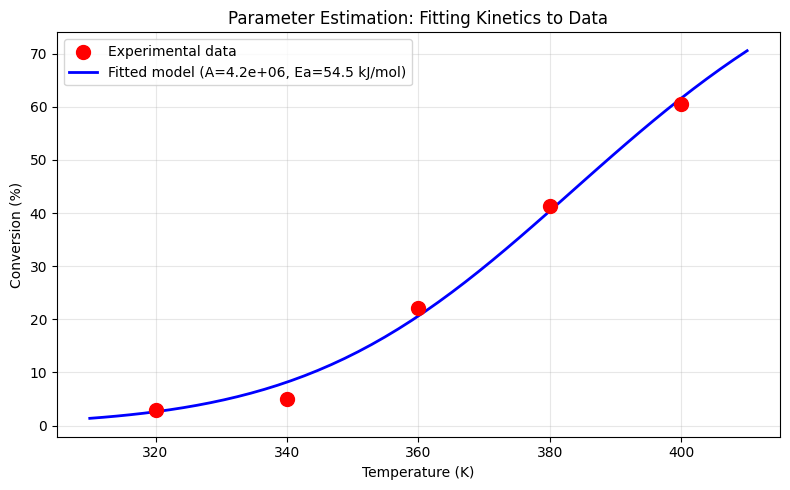

In [8]:
def loss(params: Array) -> Array:
    """Sum of squared errors between model and data."""
    log_A, Ea = params[0], params[1]
    
    def model_X(T):
        cstr = create_cstr(jnp.array(1.0), {"A": jnp.exp(log_A), "Ea": Ea})
        inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
        _, info = cstr(inlet, T_spec=T)
        return info["conversion"]["A"]
    
    predictions = jnp.array([model_X(T) for T in temperatures])
    return jnp.sum((predictions - experimental_X) ** 2)


# Initial guess (deliberately wrong)
x0 = jnp.array([jnp.log(1e5), 40000.0])  # A=1e5, Ea=40 kJ/mol

print(f"Initial guess: A = {jnp.exp(x0[0]):.2e}, Ea = {x0[1]/1000:.1f} kJ/mol")
print(f"Initial loss: {float(loss(x0)):.6f}")

print("\nFitting parameters using jaxopt.LBFGS...")

# Use L-BFGS for this smooth optimization problem
solver = jaxopt.LBFGS(fun=loss, maxiter=500, tol=1e-10)
result = solver.run(x0)
x_opt = result.params

estimated_A = jnp.exp(x_opt[0])
estimated_Ea = x_opt[1]

print(f"\n✓ Estimated parameters:")
print(f"  A  = {float(estimated_A):.2e} (true: {float(jnp.exp(true_log_A)):.2e})")
print(f"  Ea = {float(estimated_Ea)/1000:.2f} kJ/mol (true: {true_Ea/1000:.2f})")
print(f"\nFinal loss: {float(loss(x_opt)):.8f}")
print(f"\nRelative errors:")
print(f"  A:  {abs(float(estimated_A) - float(jnp.exp(true_log_A)))/float(jnp.exp(true_log_A))*100:.2f}%")
print(f"  Ea: {abs(float(estimated_Ea) - true_Ea)/true_Ea*100:.2f}%")

# Visualization: Model fit vs data
fig, ax = plt.subplots(figsize=(8, 5))

# Plot experimental data
ax.scatter(temperatures, experimental_X * 100, s=100, c='red', marker='o', 
           label='Experimental data', zorder=5)

# Plot model predictions with fitted parameters
T_fine = jnp.linspace(310, 410, 50)
def fitted_X(T):
    cstr = create_cstr(jnp.array(1.0), {"A": estimated_A, "Ea": estimated_Ea})
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    _, info = cstr(inlet, T_spec=T)
    return float(info["conversion"]["A"])

X_fitted = [fitted_X(T) * 100 for T in T_fine]
ax.plot(T_fine, X_fitted, 'b-', lw=2, label=f'Fitted model (A={float(estimated_A):.1e}, Ea={float(estimated_Ea)/1000:.1f} kJ/mol)')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Conversion (%)')
ax.set_title('Parameter Estimation: Fitting Kinetics to Data')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Pareto Analysis: Multi-Objective Trade-offs

Often we have competing objectives. The **Pareto front** shows optimal trade-offs.

**Objectives**:
- Maximize conversion
- Minimize cost

We use the **weighted sum method** to generate Pareto-optimal points.

Generating Pareto front: Conversion vs Cost
Using: jaxopt.ProjectedGradient with weighted sum method



Pareto-optimal solutions (subset):
  Conversion   Cost($)    V(m³)   T(K)
  ──────────────────────────────────────
      0.1%       1000    0.10   300.0
      0.1%       1000    0.10   300.0
      0.1%       1000    0.10   300.0
      0.1%       1000    0.10   300.0
      0.1%       1000    0.10   300.0

Interpretation:
  - 100 random designs shown in gray (all dominated)
  - 25 Pareto-optimal designs on the frontier
  - Any point above/left of the Pareto front is dominated
  - Dominated = there exists a design with higher X AND lower cost


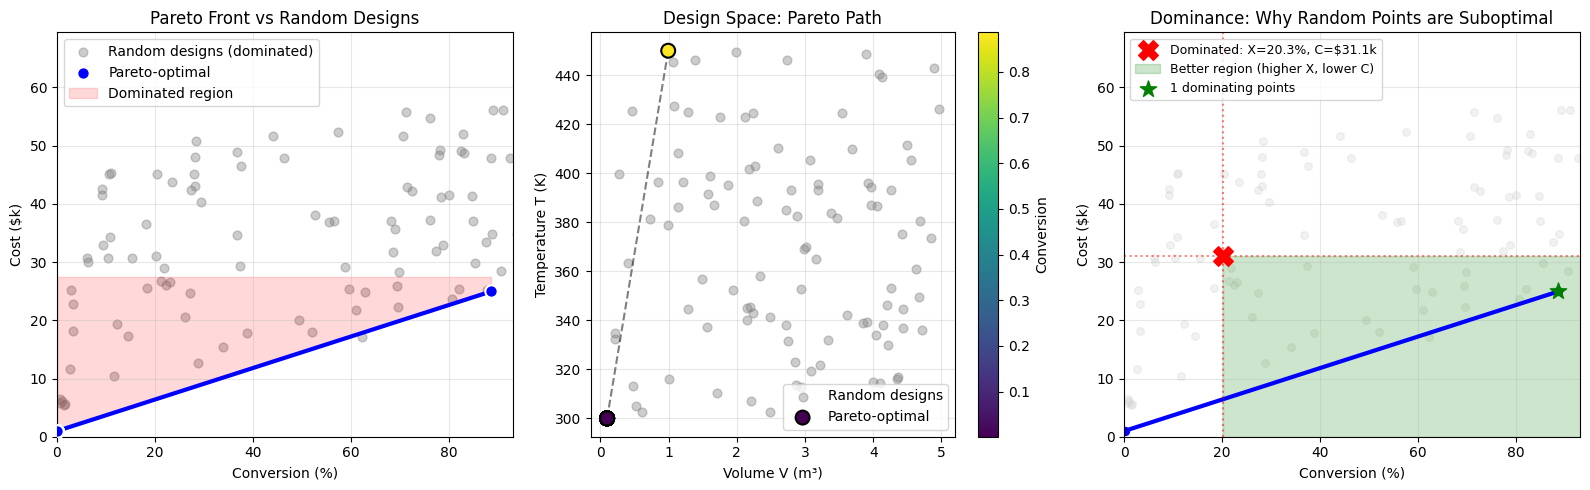

In [9]:
def cost(V, T):
    return float(V) * 10000.0 + float(T - 300.0) * 100.0

def conversion(V, T):
    cstr = create_cstr(V, {"A": jnp.array(1e6), "Ea": jnp.array(50000.0)})
    inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
    _, info = cstr(inlet, T_spec=T)
    return float(info["conversion"]["A"])


print("Generating Pareto front: Conversion vs Cost")
print("Using: jaxopt.ProjectedGradient with weighted sum method\n")

pareto_points = []

for alpha in jnp.linspace(0.01, 0.99, 25):
    def weighted_obj(params):
        V, T = params[0], params[1]
        cstr = create_cstr(V, {"A": jnp.array(1e6), "Ea": jnp.array(50000.0)})
        inlet = make_stream({"A": 10.0, "B": 0.0}, T=300.0, P=101325.0)
        _, info = cstr(inlet, T_spec=T)
        
        X = info["conversion"]["A"]
        C = V * 10.0 + (T - 300.0) * 0.1  # Scaled cost
        return alpha * (-X) + (1 - alpha) * C
    
    x_opt, _ = optimize_bounded(
        weighted_obj,
        x0=jnp.array([1.0, 350.0]),
        lower=jnp.array([0.1, 300.0]),
        upper=jnp.array([5.0, 450.0]),
        maxiter=200,
    )
    
    X = conversion(x_opt[0], x_opt[1])
    C = cost(x_opt[0], x_opt[1])
    pareto_points.append((X, C, float(x_opt[0]), float(x_opt[1])))

pareto_points.sort(key=lambda p: p[0])

# Generate non-Pareto (random/suboptimal) points for comparison
key = jax.random.PRNGKey(123)
n_random = 100
V_random = jax.random.uniform(key, (n_random,), minval=0.1, maxval=5.0)
key, _ = jax.random.split(key)
T_random = jax.random.uniform(key, (n_random,), minval=300.0, maxval=450.0)

random_points = []
for i in range(n_random):
    X = conversion(V_random[i], T_random[i])
    C = cost(float(V_random[i]), float(T_random[i]))
    random_points.append((X, C, float(V_random[i]), float(T_random[i])))

print("Pareto-optimal solutions (subset):")
print("  Conversion   Cost($)    V(m³)   T(K)")
print("  " + "─" * 38)
for X, C, V, T in pareto_points[::5]:  # Show every 5th point
    print(f"    {X*100:5.1f}%    {C:7.0f}   {V:5.2f}   {T:5.1f}")

# Visualization: Pareto front with non-Pareto points
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Pareto front with random points
ax1 = axes[0]
# Plot random (non-Pareto) points first
X_rand = [p[0]*100 for p in random_points]
C_rand = [p[1]/1000 for p in random_points]
ax1.scatter(X_rand, C_rand, c='gray', alpha=0.4, s=40, label='Random designs (dominated)')
# Plot Pareto front
X_pareto = [p[0]*100 for p in pareto_points]
C_pareto = [p[1]/1000 for p in pareto_points]
ax1.plot(X_pareto, C_pareto, 'b-', lw=3, zorder=5)
ax1.scatter(X_pareto, C_pareto, c='blue', s=80, zorder=6, edgecolors='white', 
            linewidths=1.5, label='Pareto-optimal')
# Shade dominated region
ax1.fill_between(X_pareto, C_pareto, max(C_pareto)*1.1, alpha=0.15, color='red', 
                  label='Dominated region')
ax1.set_xlabel('Conversion (%)')
ax1.set_ylabel('Cost ($k)')
ax1.set_title('Pareto Front vs Random Designs')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(X_pareto)*1.05)
ax1.set_ylim(0, max(C_rand)*1.1)

# Middle: Design space showing Pareto vs non-Pareto
ax2 = axes[1]
# Random points
V_rand_vals = [p[2] for p in random_points]
T_rand_vals = [p[3] for p in random_points]
ax2.scatter(V_rand_vals, T_rand_vals, c='gray', alpha=0.4, s=40, label='Random designs')
# Pareto points colored by conversion
V_pareto = [p[2] for p in pareto_points]
T_pareto = [p[3] for p in pareto_points]
colors = [p[0] for p in pareto_points]
sc = ax2.scatter(V_pareto, T_pareto, c=colors, cmap='viridis', s=100, 
                  edgecolors='black', linewidths=1.5, zorder=5, label='Pareto-optimal')
ax2.plot(V_pareto, T_pareto, 'k--', alpha=0.5, zorder=4)
ax2.set_xlabel('Volume V (m³)')
ax2.set_ylabel('Temperature T (K)')
ax2.set_title('Design Space: Pareto Path')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
plt.colorbar(sc, ax=ax2, label='Conversion')

# Right: Dominance visualization - pick a specific dominated point
ax3 = axes[2]
# Find a dominated point to highlight
dominated_idx = 50  # Pick one random point
dom_X, dom_C, dom_V, dom_T = random_points[dominated_idx]
# Find Pareto points that dominate it
dominating = [(X, C) for X, C, _, _ in pareto_points if X >= dom_X and C <= dom_C]

ax3.scatter(X_rand, C_rand, c='lightgray', alpha=0.3, s=30)
ax3.plot(X_pareto, C_pareto, 'b-', lw=3)
ax3.scatter(X_pareto, C_pareto, c='blue', s=60, edgecolors='white', linewidths=1)
# Highlight dominated point
ax3.scatter([dom_X*100], [dom_C/1000], c='red', s=200, marker='X', zorder=10,
            label=f'Dominated: X={dom_X*100:.1f}%, C=${dom_C/1000:.1f}k')
# Draw dominance region
ax3.axhline(dom_C/1000, color='red', ls=':', alpha=0.5)
ax3.axvline(dom_X*100, color='red', ls=':', alpha=0.5)
# Shade the "better" region
ax3.fill_between([dom_X*100, max(X_pareto)*1.1], 0, dom_C/1000, 
                  alpha=0.2, color='green', label='Better region (higher X, lower C)')
if dominating:
    dom_pts_X = [p[0]*100 for p in dominating]
    dom_pts_C = [p[1]/1000 for p in dominating]
    ax3.scatter(dom_pts_X, dom_pts_C, c='green', s=150, marker='*', zorder=11,
                label=f'{len(dominating)} dominating points')
ax3.set_xlabel('Conversion (%)')
ax3.set_ylabel('Cost ($k)')
ax3.set_title('Dominance: Why Random Points are Suboptimal')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(X_pareto)*1.05)
ax3.set_ylim(0, max(C_rand)*1.1)

plt.tight_layout()

print("\nInterpretation:")
print(f"  - {n_random} random designs shown in gray (all dominated)")
print(f"  - {len(pareto_points)} Pareto-optimal designs on the frontier")
print("  - Any point above/left of the Pareto front is dominated")
print("  - Dominated = there exists a design with higher X AND lower cost")

## Summary

This notebook demonstrated various optimization scenarios using **JAX-native optimizers**:

| Scenario | Optimizer | Why This Choice |
|----------|-----------|-----------------|
| Optimal T (1D) | `jaxopt.ProjectedGradient` | Simple bounded optimization |
| V + T jointly | `jaxopt.ProjectedGradient` | Penalty method with bounds |
| Economic | `jaxopt.ProjectedGradient` | Bounded profit maximization |
| Parameter estimation | `jaxopt.LBFGS` | Smooth unconstrained - fast convergence |
| Pareto analysis | `jaxopt.ProjectedGradient` | Weighted sum with bounds |

**Key advantages of JAX-native optimizers**:
1. **Exact gradients** from automatic differentiation (no finite differences)
2. **JIT compilation** for fast execution
3. **GPU/TPU ready** - same code scales to accelerators
4. **Composable** - works with other JAX transformations (vmap, etc.)

**Optimizer selection guide**:
- **L-BFGS** (`jaxopt.LBFGS`): Best for smooth problems - uses curvature information
- **ProjectedGradient** (`jaxopt.ProjectedGradient`): When you have bound constraints
- **GradientDescent** (`jaxopt.GradientDescent`): Simple cases or when tuning step size
- **Adam** (`optax.adam`): Stochastic/noisy problems, deep learning